In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
years = [2018, 2019, 2021, 2022, 2023, 2024, 2025]

In [3]:
def get_race_results(year):
    session = fastf1.get_session(year, "Monaco", "R")
    session.load()

    results = session.results

    return results

In [4]:
results_2025 = get_race_results(2025)

req         WARNING 	DEFAULT CACHE ENABLED! (101.69 MB) C:\Users\HP-VICTUS\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '1', '44', '6', '31', '30', '23', '55', '63', '87', '43', '5'

In [5]:
results_2025[["FullName", "GridPosition", "Position", "Status"]]

,FullName,GridPosition,Position,Status
4,Lando Norris,1.0,1.0,Finished
16,Charles Leclerc,2.0,2.0,Finished
81,Oscar Piastri,3.0,3.0,Finished
1,Max Verstappen,4.0,4.0,Finished
44,Lewis Hamilton,7.0,5.0,Finished
6,Isack Hadjar,5.0,6.0,Lapped
31,Esteban Ocon,8.0,7.0,Lapped
30,Liam Lawson,9.0,8.0,Lapped
23,Alexander Albon,10.0,9.0,Lapped
55,Carlos Sainz,11.0,10.0,Lapped


In [6]:
def get_race_results(year):
    session = fastf1.get_session(year, "Monaco", "R")
    session.load()

    results = session.results

    columns = [
        "FullName",
        "TeamName",
        "GridPosition",
        "Position",
        "ClassifiedPosition",
        "Status",
        "Points",
        "Laps",
        "Time"
    ]

    results = results[columns].copy()

    results["Year"] = year

    return results

In [7]:
results_2025 = get_race_results(2025)

results_2025.head()

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '1', '44', '6', '31', '30', '23', '55', '63', '87', '43', '5', '18', '27', '22', '12', '14', '10']


,FullName,TeamName,GridPosition,Position,ClassifiedPosition,Status,Points,Laps,Time,Year
4,Lando Norris,McLaren,1.0,1.0,1,Finished,25.0,78.0,0 days 01:40:33.843000,2025
16,Charles Leclerc,Ferrari,2.0,2.0,2,Finished,18.0,78.0,0 days 00:00:03.131000,2025
81,Oscar Piastri,McLaren,3.0,3.0,3,Finished,15.0,78.0,0 days 00:00:03.658000,2025
1,Max Verstappen,Red Bull Racing,4.0,4.0,4,Finished,12.0,78.0,0 days 00:00:20.572000,2025
44,Lewis Hamilton,Ferrari,7.0,5.0,5,Finished,10.0,78.0,0 days 00:00:51.387000,2025


In [8]:
results_2025.shape

(20, 10)

In [9]:
results_2025["PositionsGained"] = (
    results_2025["GridPosition"] - results_2025["Position"]
)

In [10]:
results_2025['PositionsGained']

4      0.0
16     0.0
81     0.0
1      0.0
44     2.0
6     -1.0
31     1.0
30     1.0
23     1.0
55     1.0
63     3.0
87     8.0
43     5.0
5      2.0
18     4.0
27    -3.0
22    -5.0
12    -3.0
14   -13.0
10    -3.0
Name: PositionsGained, dtype: float64

In [14]:
all_results = []

In [15]:
for year in years:
    result = get_race_results(year)
    all_results.append(result)

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 3 completed the race distance 00:00.040000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['3', '5', '44', '7', '77', '31', '10', '27', '33', '55', '9', '11', '20', '2', '8', '35', '18', '16', '28', '14']
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loadi

In [16]:
historical_results = pd.concat(all_results, ignore_index=True)

In [17]:
historical_results.shape

(140, 10)

In [18]:
historical_results.head()

,FullName,TeamName,GridPosition,Position,ClassifiedPosition,Status,Points,Laps,Time,Year
0,Daniel Ricciardo,Red Bull Racing,1.0,1.0,1,Finished,25.0,78.0,0 days 01:42:54.807000,2018
1,Sebastian Vettel,Ferrari,2.0,2.0,2,Finished,18.0,78.0,0 days 00:00:07.336000,2018
2,Lewis Hamilton,Mercedes,3.0,3.0,3,Finished,15.0,78.0,0 days 00:00:17.013000,2018
3,Kimi Räikkönen,Ferrari,4.0,4.0,4,Finished,12.0,78.0,0 days 00:00:18.127000,2018
4,Valtteri Bottas,Mercedes,5.0,5.0,5,Finished,10.0,78.0,0 days 00:00:18.822000,2018


In [19]:
historical_results.tail()

,FullName,TeamName,GridPosition,Position,ClassifiedPosition,Status,Points,Laps,Time,Year
135,Nico Hulkenberg,Kick Sauber,13.0,16.0,16,Lapped,0.0,76.0,0 days 00:01:11.544000,2025
136,Yuki Tsunoda,Red Bull Racing,12.0,17.0,17,Lapped,0.0,76.0,0 days 00:01:11.849000,2025
137,Kimi Antonelli,Mercedes,15.0,18.0,18,Lapped,0.0,75.0,0 days 00:00:08.409000,2025
138,Fernando Alonso,Aston Martin,6.0,19.0,R,Retired,0.0,36.0,NaT,2025
139,Pierre Gasly,Alpine,17.0,20.0,R,Retired,0.0,7.0,NaT,2025


In [20]:
historical_results["Year"].value_counts().sort_index()

Year
2018    20
2019    20
2021    20
2022    20
2023    20
2024    20
2025    20
Name: count, dtype: int64

In [21]:
historical_results.info()

<class 'fastf1.core.SessionResults'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   FullName            140 non-null    object         
 1   TeamName            140 non-null    object         
 2   GridPosition        140 non-null    float64        
 3   Position            140 non-null    float64        
 4   ClassifiedPosition  140 non-null    object         
 5   Status              140 non-null    object         
 6   Points              140 non-null    float64        
 7   Laps                140 non-null    float64        
 8   Time                97 non-null     timedelta64[ns]
 9   Year                140 non-null    int64          
dtypes: float64(4), int64(1), object(4), timedelta64[ns](1)
memory usage: 11.1+ KB


In [22]:
historical_results.isna().sum()

FullName               0
TeamName               0
GridPosition           0
Position               0
ClassifiedPosition     0
Status                 0
Points                 0
Laps                   0
Time                  43
Year                   0
dtype: int64

In [23]:
historical_results["Year"].value_counts().sort_index()

Year
2018    20
2019    20
2021    20
2022    20
2023    20
2024    20
2025    20
Name: count, dtype: int64

In [24]:
status_by_year = pd.crosstab(
    historical_results["Year"],
    historical_results["Status"]
)

status_by_year

Status,+1 Lap,+2 Laps,+3 Laps,Accident,Collision,Driveshaft,Finished,Gearbox,Lapped,Mechanical,Retired,Water pressure,Wheel nut
Year,,,,,,,,,,,,,
2018,3,1,0,0,2,0,13,1,0,0,0,0,0
2019,7,1,0,0,1,0,11,0,0,0,0,0,0
2021,9,0,2,0,0,1,7,0,0,0,0,0,1
2022,3,0,0,1,0,0,14,0,0,1,0,1,0
2023,0,0,0,0,0,0,8,0,10,0,2,0,0
2024,0,0,0,0,0,0,7,0,9,0,4,0,0
2025,0,0,0,0,0,0,5,0,13,0,2,0,0


In [25]:
lapped_percentage = (
    historical_results.groupby("Year")["Status"]
    .apply(lambda x: (x == "Lapped").mean() * 100)
)

lapped_percentage

Year
2018     0.0
2019     0.0
2021     0.0
2022     0.0
2023    50.0
2024    45.0
2025    65.0
Name: Status, dtype: float64

In [26]:
lapped_statuses = [
    "Lapped",
    "+1 Lap",
    "+2 Laps",
    "+3 Laps"
]

In [27]:
lapped_percentage = (
    historical_results.groupby("Year")["Status"]
    .apply(lambda x: x.isin(lapped_statuses).mean() * 100)
)

lapped_percentage

Year
2018    20.0
2019    40.0
2021    55.0
2022    15.0
2023    50.0
2024    45.0
2025    65.0
Name: Status, dtype: float64

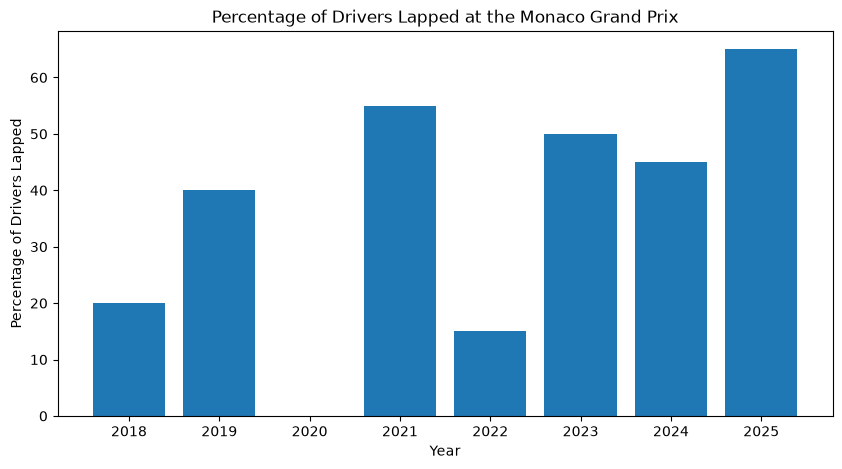

In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    lapped_percentage.index,
    lapped_percentage.values
)

plt.xlabel("Year")
plt.ylabel("Percentage of Drivers Lapped")
plt.title("Percentage of Drivers Lapped at the Monaco Grand Prix")

plt.show()

In [29]:
race_spread = (
    historical_results
    .dropna(subset=["Time"])
    .groupby("Year")["Time"]
    .max()
)

In [30]:
race_spread_seconds = race_spread.dt.total_seconds()

In [31]:
race_spread_seconds

Year
2018    6174.807
2019    6208.437
2021    5936.820
2022    6990.265
2023    6531.980
2024    8595.554
2025    6033.843
Name: Time, dtype: float64

In [32]:
historical_results[
    historical_results["Year"] == 2024
][
    ["FullName", "Position", "Status", "Time"]
]

,FullName,Position,Status,Time
100,Charles Leclerc,1.0,Finished,0 days 02:23:15.554000
101,Oscar Piastri,2.0,Finished,0 days 00:00:07.152000
102,Carlos Sainz,3.0,Finished,0 days 00:00:07.585000
103,Lando Norris,4.0,Finished,0 days 00:00:08.650000
104,George Russell,5.0,Finished,0 days 00:00:13.309000
105,Max Verstappen,6.0,Finished,0 days 00:00:13.853000
106,Lewis Hamilton,7.0,Finished,0 days 00:00:14.908000
107,Yuki Tsunoda,8.0,Lapped,0 days 00:00:39.487000
108,Alexander Albon,9.0,Lapped,0 days 00:00:54.052000
109,Pierre Gasly,10.0,Lapped,0 days 00:01:00.241000


In [ ]:
historical_results["PositionsGained"] = (
    historical_results["GridPosition"] - historical_results["Position"]
)

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
135    -3.0
136    -5.0
137    -3.0
138   -13.0
139    -3.0
Name: PositionsGained, Length: 140, dtype: float64

In [34]:
historical_results[
    ["Year", "FullName", "GridPosition", "Position", "PositionsGained"]
].head(20)

,Year,FullName,GridPosition,Position,PositionsGained
0,2018,Daniel Ricciardo,1.0,1.0,0.0
1,2018,Sebastian Vettel,2.0,2.0,0.0
2,2018,Lewis Hamilton,3.0,3.0,0.0
3,2018,Kimi Räikkönen,4.0,4.0,0.0
4,2018,Valtteri Bottas,5.0,5.0,0.0
5,2018,Esteban Ocon,6.0,6.0,0.0
6,2018,Pierre Gasly,10.0,7.0,3.0
7,2018,Nico Hulkenberg,11.0,8.0,3.0
8,2018,Max Verstappen,20.0,9.0,11.0
9,2018,Carlos Sainz,8.0,10.0,-2.0


In [35]:
biggest_gainers = (
    historical_results
    .loc[historical_results["PositionsGained"].idxmax()]
)

biggest_gainers

FullName                      Max Verstappen
TeamName                     Red Bull Racing
GridPosition                            20.0
Position                                 9.0
ClassifiedPosition                         9
Status                              Finished
Points                                   2.0
Laps                                    78.0
Time                  0 days 00:00:25.317000
Year                                    2018
PositionsGained                         11.0
Name: 8, dtype: object

In [36]:
biggest_losers = (
    historical_results
    .loc[historical_results["PositionsGained"].idxmin()]
)

biggest_losers

FullName              Charles Leclerc
TeamName                      Ferrari
GridPosition                      1.0
Position                         20.0
ClassifiedPosition                  W
Status                     Driveshaft
Points                            0.0
Laps                              0.0
Time                              NaT
Year                             2021
PositionsGained                 -19.0
Name: 59, dtype: object

In [37]:
biggest_gainers = (
    historical_results
    .loc[
        historical_results.groupby("Year")["PositionsGained"].idxmax()
    ]
)

biggest_gainers[
    ["Year", "FullName", "TeamName", "GridPosition", "Position", "PositionsGained"]
]

,Year,FullName,TeamName,GridPosition,Position,PositionsGained
8,2018,Max Verstappen,Red Bull Racing,20.0,9.0,11.0
31,2019,Sergio Perez,Racing Point,16.0,12.0,4.0
43,2021,Sergio Perez,Red Bull Racing,9.0,4.0,5.0
70,2022,Pierre Gasly,AlphaTauri,17.0,11.0,6.0
92,2023,Guanyu Zhou,Alfa Romeo,19.0,13.0,6.0
112,2024,Valtteri Bottas,Kick Sauber,17.0,13.0,4.0
131,2025,Oliver Bearman,Haas F1 Team,20.0,12.0,8.0


In [38]:
biggest_losers = (
    historical_results
    .loc[
        historical_results.groupby("Year")["PositionsGained"].idxmin()
    ]
)

biggest_losers[
    ["Year", "FullName", "TeamName", "GridPosition", "Position", "PositionsGained"]
]

,Year,FullName,TeamName,GridPosition,Position,PositionsGained
19,2018,Fernando Alonso,McLaren,7.0,20.0,-13.0
33,2019,Kevin Magnussen,Haas F1 Team,5.0,14.0,-9.0
59,2021,Charles Leclerc,Ferrari,1.0,20.0,-19.0
79,2022,Kevin Magnussen,Haas F1 Team,13.0,20.0,-7.0
94,2023,Yuki Tsunoda,AlphaTauri,9.0,15.0,-6.0
116,2024,Esteban Ocon,Alpine,11.0,17.0,-6.0
138,2025,Fernando Alonso,Aston Martin,6.0,19.0,-13.0


In [39]:
finishers = historical_results[
    historical_results["Status"].isin(["Finished", "Lapped", "+1 Lap", "+2 Laps", "+3 Laps"])
].copy()

In [41]:
retirements = historical_results[
    ~historical_results["Status"].isin(["Finished", "Lapped", "+1 Lap", "+2 Laps", "+3 Laps"])
].copy()

In [ ]:
finishers.shape

(123, 11)

In [44]:
retirements.shape

(17, 11)

In [45]:
finishers["StartingGroup"] = pd.cut(
    finishers["GridPosition"],
    bins=[0, 6, 14, 20],
    labels=["Front", "Midfield", "Back"]
)

In [46]:
finishers.groupby("StartingGroup", observed=True)["PositionsGained"].mean()

StartingGroup
Front      -0.282051
Midfield    0.333333
Back        3.030303
Name: PositionsGained, dtype: float64

In [48]:
finishers.groupby("StartingGroup", observed=True)["PositionsGained"].agg(
    ["mean", "median", "count"]
)

,mean,median,count
StartingGroup,,,
Front,-0.282051,0.0,39
Midfield,0.333333,0.0,51
Back,3.030303,4.0,33


In [49]:
back_starters = finishers[
    finishers["StartingGroup"] == "Back"
]

back_starters[
    [
        "Year",
        "FullName",
        "GridPosition",
        "Position",
        "PositionsGained",
        "Status"
    ]
].sort_values(
    "PositionsGained",
    ascending=False
)

,Year,FullName,GridPosition,Position,PositionsGained,Status
8,2018,Max Verstappen,20.0,9.0,11.0,Finished
131,2025,Oliver Bearman,20.0,12.0,8.0,Lapped
12,2018,Kevin Magnussen,19.0,13.0,6.0,Finished
92,2023,Guanyu Zhou,19.0,13.0,6.0,Lapped
70,2022,Pierre Gasly,17.0,11.0,6.0,Finished
10,2018,Marcus Ericsson,16.0,11.0,5.0,Finished
132,2025,Franco Colapinto,18.0,13.0,5.0,Lapped
52,2021,Fernando Alonso,17.0,13.0,4.0,+1 Lap
34,2019,George Russell,19.0,15.0,4.0,+1 Lap
74,2022,Nicholas Latifi,19.0,15.0,4.0,+1 Lap


In [50]:
retirements_by_year = (
    retirements.groupby("Year")
    .size()
)

retirements_by_year

Year
2018    3
2019    1
2021    2
2022    3
2023    2
2024    4
2025    2
dtype: int64

In [51]:
back_gain_by_year = (
    back_starters.groupby("Year")["PositionsGained"]
    .mean()
)

back_gain_by_year

Year
2018    5.0
2019    2.0
2021    2.0
2022    4.5
2023    2.6
2024    2.0
2025    3.2
Name: PositionsGained, dtype: float64

In [52]:
comparison = pd.DataFrame({
    "Retirements": retirements_by_year,
    "BackStarterGain": back_gain_by_year
})

comparison

,Retirements,BackStarterGain
Year,,
2018,3,5.0
2019,1,2.0
2021,2,2.0
2022,3,4.5
2023,2,2.6
2024,4,2.0
2025,2,3.2


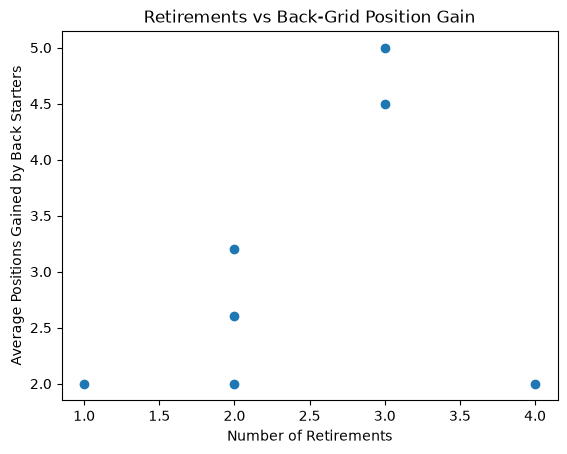

In [53]:
plt.scatter(
    comparison["Retirements"],
    comparison["BackStarterGain"]
)

plt.xlabel("Number of Retirements")
plt.ylabel("Average Positions Gained by Back Starters")
plt.title("Retirements vs Back-Grid Position Gain")
plt.show()

In [54]:
historical_results[
    historical_results["Year"] == 2024
][
    [
        "FullName",
        "GridPosition",
        "Position",
        "PositionsGained",
        "Status"
    ]
].sort_values("GridPosition")

,FullName,GridPosition,Position,PositionsGained,Status
100,Charles Leclerc,1.0,1.0,0.0,Finished
101,Oscar Piastri,2.0,2.0,0.0,Finished
102,Carlos Sainz,3.0,3.0,0.0,Finished
103,Lando Norris,4.0,4.0,0.0,Finished
104,George Russell,5.0,5.0,0.0,Finished
105,Max Verstappen,6.0,6.0,0.0,Finished
106,Lewis Hamilton,7.0,7.0,0.0,Finished
107,Yuki Tsunoda,8.0,8.0,0.0,Lapped
108,Alexander Albon,9.0,9.0,0.0,Lapped
109,Pierre Gasly,10.0,10.0,0.0,Lapped


In [55]:
retirement_grid_position = (
    retirements
    .groupby("Year")["GridPosition"]
    .mean()
)

retirement_grid_position

Year
2018    12.000000
2019    15.000000
2021     2.000000
2022    14.666667
2023    15.500000
2024    16.500000
2025    11.500000
Name: GridPosition, dtype: float64

In [56]:
retirements[
    retirements["Year"] == 2021
][
    [
        "FullName",
        "GridPosition",
        "Position",
        "Status"
    ]
]

,FullName,GridPosition,Position,Status
58,Valtteri Bottas,3.0,19.0,Wheel nut
59,Charles Leclerc,1.0,20.0,Driveshaft


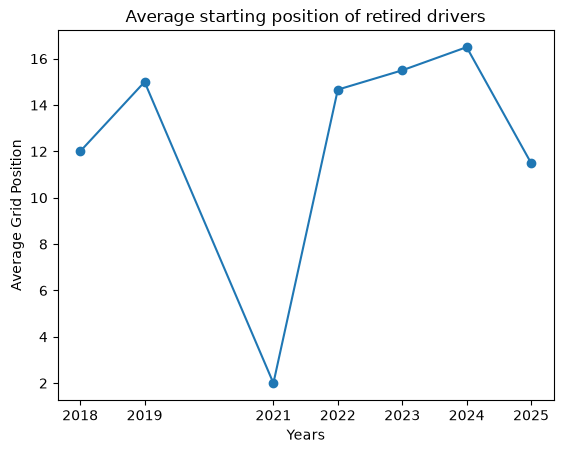

In [62]:
plt.plot(years,retirement_grid_position, marker='o')
plt.title('Average starting position of retired drivers')
plt.xlabel('Years')
plt.ylabel('Average Grid Position')
plt.xticks(years)
plt.show()